<a href="https://colab.research.google.com/github/carolineolvs/ProvaIcoma/blob/main/neuroalgoritmos_caroline_silva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Prova 34:** ANATEL | Reclamações de Serviços de Telecomunicações:

**Aluna:** Caroline Oliveira Silva

# Pipeline |  Carregamento e Extração de Dados [Fase 1]

## Bibliotecas e Configurações


In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import textwrap
import seaborn as sns

## Importar dados do Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/provaicoma/reclamacoes_contexto.csv', sep=';')

df.head()

,DataExtracao,SOLICITAÇÕES,Ano,Mês,AnoMês,UF,Cidade,CO_MUNICIPIO,CanalEntrada,Condição,TipoAtendimento,Serviço,Marca,Assunto,Problema,Linha
0,10/01/2025,1,2020,10,2020-10,SP,São Paulo,3550308,Usuário web,Nova,Reclamação,SMP_Pré,VIVO,Dados cadastrais ou número da linha,Perda de número da linha,1
1,10/01/2025,1,2020,8,2020-08,PR,Arapongas,4101507,Call center,Nova,Reclamação,STFC,VIVO,Cobrança,Cobrança em desacordo com o contratado,2
2,10/01/2025,2,2020,9,2020-09,SP,São Paulo,3550308,Mobile app,Nova,Reclamação,SMP_Pós,VIVO,Instalação ou ativação ou habilitação,Instalação ou habilitação não realizada,3
3,10/01/2025,1,2020,8,2020-08,RN,Mossoró,2408003,Mobile app,Nova,Reclamação,SCM,TCM TV CABO MOSSORO,Cobrança,Cobrança indevida de multa por fidelização (mu...,4
4,10/01/2025,1,2020,11,2020-11,AL,Maceió,2704302,Usuário web,Nova,Reclamação,SCM,CLARO,Instalação ou ativação ou habilitação,Instalação ou habilitação não realizada,5


# Pipeline | Laborização [Fase 2]

In [4]:
termos_chave = [
    'bloqueio', 'bloqueado', 'suspensão', 'suspenso', 'suspens',
    'interrupção', 'interrompido', 'sem sinal', 'linha muda',
    'sem conexão', 'sem imagem', 'indisponível',
    'desligado', 'desativado', 'cortado', 'corte'
]

In [5]:
padrao_busca = '|'.join(termos_chave)

In [6]:
df['Corte_Indevido'] = (
    df['Assunto'].str.contains(padrao_busca, case=False, na=False) |
    df['Problema'].str.contains(padrao_busca, case=False, na=False)
).astype(int)

# Pipeline | Tratamento e Normalização [Fase 3]

In [7]:
df.isnull().sum()

,0
DataExtracao,0
SOLICITAÇÕES,0
Ano,0
Mês,0
AnoMês,0
UF,0
Cidade,0
CO_MUNICIPIO,0
CanalEntrada,0
Condição,0


In [8]:
df = df.dropna(subset=['Assunto', 'Problema'])

X = df['Problema']
y = df['Corte_Indevido']

X_train_texto, X_test_texto, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(max_features=100)

X_train = vectorizer.fit_transform(X_train_texto)

X_test = vectorizer.transform(X_test_texto)

scaler = StandardScaler(with_mean=False)

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Pipeline | Visualização [Fase 4]

In [9]:
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0, 0.5, 'Quantidade')

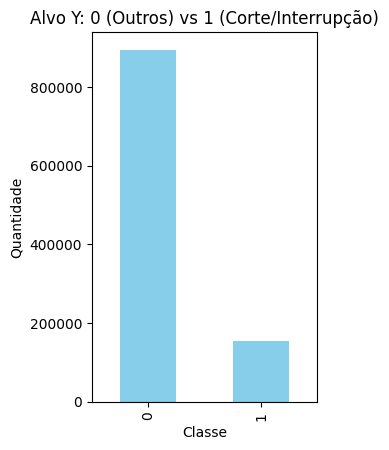

In [10]:
plt.subplot(1, 2, 1)
df['Corte_Indevido'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Alvo Y: 0 (Outros) vs 1 (Corte/Interrupção)')
plt.xlabel('Classe')
plt.ylabel('Quantidade')

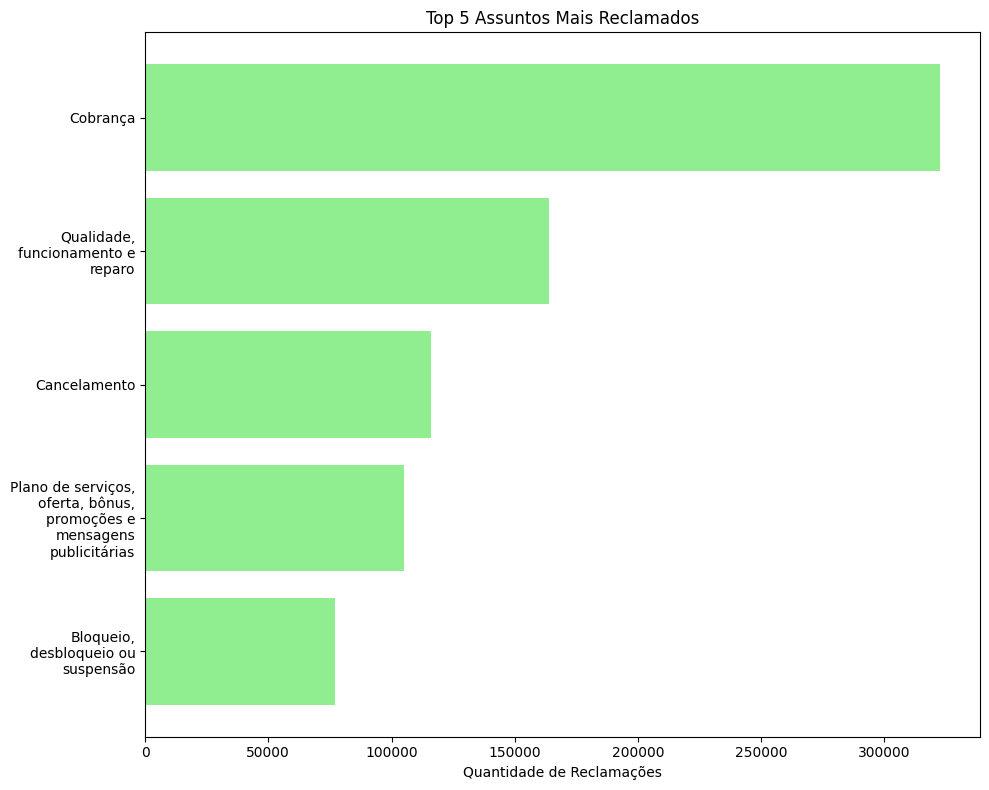

In [11]:
contagem = df['Assunto'].value_counts().head(5).sort_values(ascending=True)

nomes_quebrados = [textwrap.fill(assunto, width=20) for assunto in contagem.index]

plt.figure(figsize=(10, 8))
plt.barh(nomes_quebrados, contagem, color='lightgreen')

plt.title('Top 5 Assuntos Mais Reclamados')
plt.xlabel('Quantidade de Reclamações')

plt.tight_layout()
plt.show()

# Pipeline - Sistema Inteligente 1 — Árvore de Decisão [Fase 5]

In [12]:
arvore = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)
arvore.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

In [13]:
y_pred_arvore = arvore.predict(X_test)

In [14]:
y_pred_arvore

array([0, 1, 1, ..., 0, 1, 1])

In [15]:
accuracy_score(y_test, y_pred_arvore)

0.9986219392985719

In [16]:
confusion_matrix(y_test, y_pred_arvore)

array([[178844,      0],
       [   289,  30582]])

In [17]:
print("Árvore de Decisão")
print(classification_report(y_test, y_pred_arvore))

Árvore de Decisão
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    178844
           1       1.00      0.99      1.00     30871

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715



# Pipeline - Sistema Inteligente 2 — Random Forest [Fase 6]

In [18]:
floresta = RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=5, random_state=0)

In [19]:
floresta.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=5, random_state=0)

In [20]:
floresta

RandomForestClassifier(criterion='entropy', max_depth=5, random_state=0)

In [21]:
y_pred_floresta = floresta.predict(X_test)

In [22]:
y_pred_floresta

array([0, 0, 1, ..., 0, 1, 1])

In [23]:
accuracy_score(y_test, y_pred_floresta)

0.9686383901962187

In [24]:
confusion_matrix(y_test, y_pred_floresta)

array([[178844,      0],
       [  6577,  24294]])

In [25]:
print("Random Forest")
print(classification_report(y_test, y_pred_floresta))

Random Forest
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    178844
           1       1.00      0.79      0.88     30871

    accuracy                           0.97    209715
   macro avg       0.98      0.89      0.93    209715
weighted avg       0.97      0.97      0.97    209715



# Pipeline | Sistema Inteligente 3 — Support Vector Machine (SVM) [Fase 7]

In [26]:
svm = SVC(kernel='rbf', C=2.0, random_state=1)
svm.fit(X_train, y_train)
svm

SVC(C=2.0, random_state=1)

In [27]:
y_pred_svm = svm.predict(X_test)

In [28]:
y_pred_svm

array([0, 1, 1, ..., 0, 1, 1])

In [29]:
accuracy_score(y_test, y_pred_svm)

0.9997043606799705

In [30]:
confusion_matrix(y_test, y_pred_svm)

array([[178844,      0],
       [    62,  30809]])

In [31]:
print("Support Vector Machine")
print(classification_report(y_test, y_pred_svm))

Support Vector Machine
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    178844
           1       1.00      1.00      1.00     30871

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715



# Pipeline | Sistema Inteligente 4 — K-Nearest Neighbors (KNN) [Fase 8]

In [44]:
X_train_knn = X_train[:50000]
y_train_knn = y_train[:50000]

In [45]:
X_test_knn = X_test[:10000]
y_test_knn = y_test[:10000]

In [46]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)

In [47]:
knn.fit(X_train_knn, y_train_knn)

KNeighborsClassifier(algorithm='brute', metric='cosine', n_jobs=-1)

In [48]:
y_pred_knn = knn.predict(X_test_knn)

In [50]:
accuracy_score(y_test_knn, y_pred_knn)

0.9995

In [51]:
confusion_matrix(y_test_knn, y_pred_knn)

array([[8557,    0],
       [   5, 1438]])

In [52]:
print("K-Nearest Neighbors")
print(classification_report(y_test_knn, y_pred_knn))

K-Nearest Neighbors
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8557
           1       1.00      1.00      1.00      1443

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



# Pipeline | Sistema Inteligente 5 — Rede Neural Artificial (MLP) [Fase 9]

In [56]:
mlp = MLPClassifier(verbose=True, max_iter=1000, tol=0.000010, solver='adam', hidden_layer_sizes=(100), activation='relu')



In [57]:
mlp.fit(X_train, y_train)

Iteration 1, loss = 0.00504239
Iteration 2, loss = 0.00162765
Iteration 3, loss = 0.00162192
Iteration 4, loss = 0.00157797
Iteration 5, loss = 0.00157325
Iteration 6, loss = 0.00157016
Iteration 7, loss = 0.00157652
Iteration 8, loss = 0.00157443
Iteration 9, loss = 0.00157695
Iteration 10, loss = 0.00159066
Iteration 11, loss = 0.00157155
Iteration 12, loss = 0.00159759
Iteration 13, loss = 0.00156938
Iteration 14, loss = 0.00157732
Iteration 15, loss = 0.00154612
Iteration 16, loss = 0.00154824
Iteration 17, loss = 0.00156765
Iteration 18, loss = 0.00155944
Iteration 19, loss = 0.00156773
Iteration 20, loss = 0.00156463
Iteration 21, loss = 0.00154612
Iteration 22, loss = 0.00154135
Iteration 23, loss = 0.00154691
Iteration 24, loss = 0.00155231
Iteration 25, loss = 0.00154534
Iteration 26, loss = 0.00153609
Training loss did not improve more than tol=0.000010 for 10 consecutive epochs. Stopping.


MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [58]:
mlp.out_activation_

'logistic'

In [59]:
y_pred_mlp = mlp.predict(X_test)
y_pred_mlp

array([0, 1, 1, ..., 0, 1, 1])

In [60]:
accuracy_score(y_test, y_pred_mlp)

0.9997043606799705

In [61]:
confusion_matrix(y_test, y_pred_mlp)

array([[178844,      0],
       [    62,  30809]])

In [62]:
print("Rede Neural Artificial MLP")
print(classification_report(y_test, y_pred_mlp))

Rede Neural Artificial MLP
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    178844
           1       1.00      1.00      1.00     30871

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715



# Pipeline | Matriz Comparativa dos Sistemas Inteligentes [Fase 10]

In [63]:
resultados = pd.DataFrame({
    "Modelo": [
        "Árvore de Decisão",
        "Random Forest",
        "SVM",
        "KNN",
        "Rede Neural MLP"
    ],
    "Precisão": [
        precision_score(y_test, y_pred_arvore),
        precision_score(y_test, y_pred_floresta),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test_knn, y_pred_knn),
        precision_score(y_test, y_pred_mlp)
    ],
    "Recall": [
        recall_score(y_test, y_pred_arvore),
        recall_score(y_test, y_pred_floresta),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test_knn, y_pred_knn),
        recall_score(y_test, y_pred_mlp)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_arvore),
        f1_score(y_test, y_pred_floresta),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test_knn, y_pred_knn),
        f1_score(y_test, y_pred_mlp)
    ]
})

resultados.sort_values(by="F1-Score", ascending=False)

,Modelo,Precisão,Recall,F1-Score
2,SVM,1.0,0.997992,0.998995
4,Rede Neural MLP,1.0,0.997992,0.998995
3,KNN,1.0,0.996535,0.998264
0,Árvore de Decisão,1.0,0.990638,0.995297
1,Random Forest,1.0,0.786952,0.880776


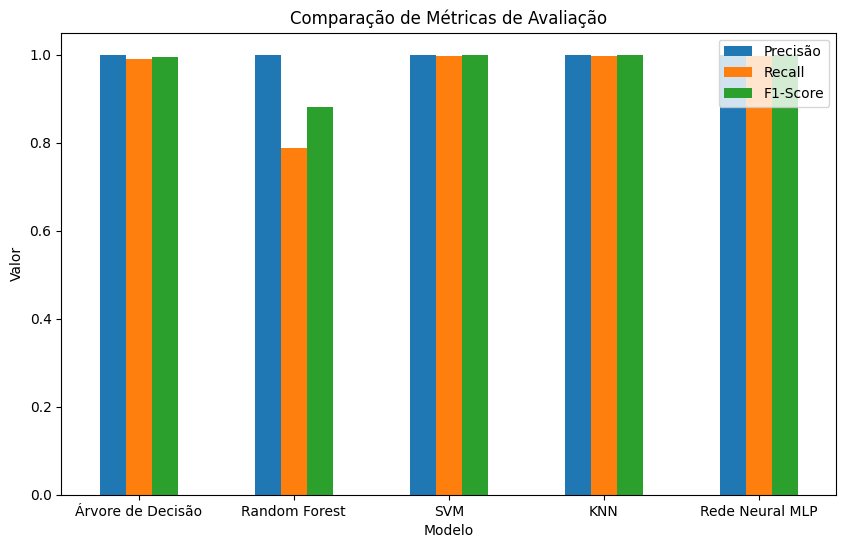

In [65]:
resultados.set_index("Modelo")[
    ['Precisão', 'Recall', 'F1-Score']
].plot(kind='bar', figsize=(10, 6))

plt.title("Comparação de Métricas de Avaliação")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.show()

In [66]:
melhor_modelo = resultados.loc[resultados['F1-Score'].idxmax()]
print(f"O melhor modelo é: {melhor_modelo}")

O melhor modelo é: Modelo           SVM
Precisão         1.0
Recall      0.997992
F1-Score    0.998995
Name: 2, dtype: object


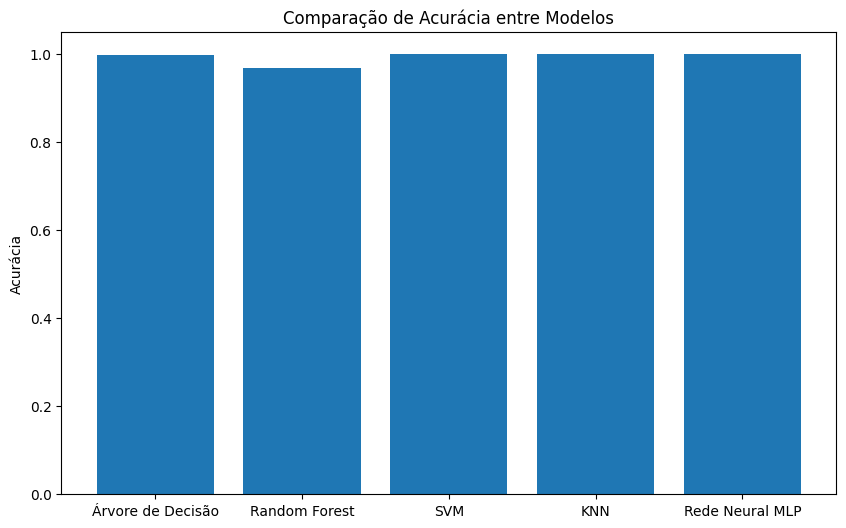

In [68]:
arvore_acc = accuracy_score(y_test, y_pred_arvore)
floresta_acc = accuracy_score(y_test, y_pred_floresta)
svm_acc = accuracy_score(y_test, y_pred_svm)
knn_acc = accuracy_score(y_test_knn, y_pred_knn)
mlp_acc = accuracy_score(y_test, y_pred_mlp)

resultados['Acurácia'] = [arvore_acc, floresta_acc, svm_acc, knn_acc, mlp_acc]

plt.figure(figsize=(10, 6))
plt.bar(resultados['Modelo'], resultados['Acurácia'])
plt.title('Comparação de Acurácia entre Modelos')
plt.ylabel('Acurácia')
plt.show()